<img src="https://raw.githubusercontent.com/Brainchip-Inc/brainchip_devhub/main/docs/assets/0.-BC-dev-hub-LOGO-flicker.svg" alt="BrainChip Dev Hub" width="200"/>

# Sparsity in Akida hardware (Akida 1)

<p align="right">
Run time: about 10 minutes on an AKD1500
</p>

Akida's neural processors (NPs) are **event-based**: a layer only processes the non-zero
values in its input, the *events*. A zero activation costs nothing. A GPU, or a
conventional NPU, multiplies a zero like any other value.

This notebook measures what that means on the chip. You will:

1. build a single layer by hand and feed it inputs with a density of events you choose, to
   see how its processing time and energy depend on the number of events;
2. compare that with what an array of multipliers of the same size would need for the
   same layer computed densely;
3. take a model zoo model, [Visual Wake Words](../../model_zoo/vww), and check that its
   layers follow the same rule on real images;
4. switch that model's sparsity off, and turn it up, to see what it is worth end to end.

**You need an Akida 1 device.** Every measurement runs on the chip. The saved outputs
were measured on an AKD1500 (PCIe). On an AKD1000, set `CLOCK_HZ` to 300 MHz below.
Energy needs an AKD1500 with power sensing; without it, those cells say so and the time
measurements still run.

Setup is in the [top-level README](../../../README.md#requirements). Section 4 uses the
VWW dataset: see the [VWW example](../../model_zoo/vww/README.md) for how to get it, and
for its licence.

In [1]:
import os
import sys

os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')

import akida
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, os.path.abspath('../../..'))              # repo root, for brainchip_utils
sys.path.insert(0, os.path.abspath('../../model_zoo/vww'))   # the VWW example's data loader

from brainchip_utils.hardware_utils import AKIDA_CLOCKS_HZ, get_akida_device, per_layer_benchmark
import sparsity_in_hardware_utils as shu
from vww_data import get_samples

device = get_akida_device(target_version=akida.IpVersion.v1)
assert device is not None, 'This tutorial needs an Akida 1 device (AKD1000 or AKD1500).'
CLOCK_HZ = AKIDA_CLOCKS_HZ['AKD1500']   # AKIDA_CLOCKS_HZ['AKD1000'] on an AKD1000
print(f'Akida device: {device.version}, clock {CLOCK_HZ / 1e6:.0f} MHz')

Target Akida device found
Akida device: BC.A1.003.009, clock 400 MHz


## How to measure one layer on the chip

Three tools are used throughout, all in
[`sparsity_in_hardware_utils.py`](sparsity_in_hardware_utils.py).

- **The chip's clock counter.** After each inference, `model.metrics['inference_clk']`
  holds the number of clock cycles the chip spent on it. It leaves out the host side (Python,
  the driver, the PCIe transfer), which depends on the host, and it is very repeatable, as
  you'll see in section 4. Divide by the clock frequency to get time.
- **Layer subtraction.** There is no counter per layer. To time one layer, run the model up
  to and including it, then up to the layer before it, and subtract. That's
  `shu.layer_clocks`.
- **A silenced last layer.** Each of those sub-models has its last layer set so that it
  never fires (`silence_output_layer` in `brainchip_utils`). It does all its processing but
  sends no events back to the host, so copying outputs off the chip isn't counted against
  whichever layer happens to be last.

Two conventions make the results simpler to read. **Density** is the fraction of values
that are non-zero, `1 - sparsity`. If each event costs a fixed time, time against density is
a straight line, `time = a × density + b`, where `a` is the cost of a full layer of events
and `b` any fixed cost. And we work in **time per inference** (clocks), not frames per
second, which would be `1 / (a × density + b)`.

## 1. One layer, with the input density under your control

`shu.build_single_layer_model` builds a three-layer Akida 1 model directly, without
Keras:

1. the input layer, with kernels that copy its single input channel to all 32 output
   channels unchanged;
2. a separable layer, also passing its input straight through. It is there so the layer
   under test receives its events from a standard NP, as it would in a real model;
3. the **layer under test**: a 3 × 3 convolution with 32 filters and random 4-bit weights.

The input is a 32 × 32 single-channel image of zeros and ones, with ones at random
positions. So the event density you put in is exactly the density the layer under test
receives.

In [2]:
HEIGHT, WIDTH, CHANNELS, FILTERS = 32, 32, 32, 32

model = shu.build_single_layer_model(HEIGHT, WIDTH, CHANNELS, FILTERS, kernel_size=3)
model.map(device, mode=akida.MapMode.Minimal)
model.summary()

                                     Model Summary                                     
_______________________________________________________________________________________
Input shape  Output shape  Sequences  Layers  NPs  Skip DMAs  External Memory (Bytes)
[32, 32, 1]  [32, 32, 32]  1          3       2    0          0                      
_______________________________________________________________________________________

_________________________
Component (type)  Count
HRC               1    
_________________________
CNP1              2    
_________________________

____________________________________________________________________
Layer (type)              Output shape  Kernel shape    Components

======= HW/InputConv_1-Conv_3 (Hardware) - size: 11552 bytes =======

InputConv_1 (InputConv.)  [32, 32, 32]  (3, 3, 1, 32)   1 HRC     
____________________________________________________________________
SepConv_2 (Sep.Conv.)     [32, 32, 32]  (3, 3, 32, 1)   1 CNP1    
__

Every layer sits on a single NP (`MapMode.Minimal`), so the layer under test does all its
work on one NP. Here is what inputs at three densities look like:

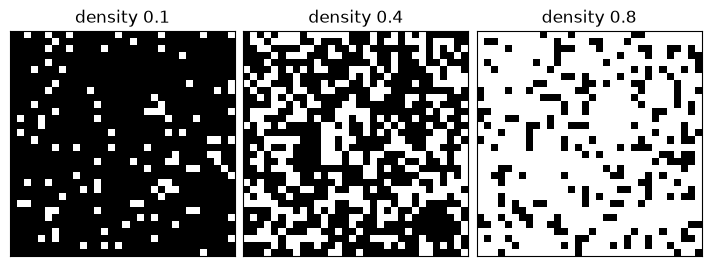

In [3]:
fig, axs = plt.subplots(1, 3, figsize=(7, 2.6), constrained_layout=True)
for ax, density in zip(axs, [0.1, 0.4, 0.8]):
    ax.imshow(shu.random_events((HEIGHT, WIDTH, 1), density, seed=0)[0, :, :, 0], cmap='bone')
    ax.set_title(f'density {density}')
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

Now sweep the density from 0 to 1, with 20 different random inputs at each step, and time
the layer by subtraction.

In [4]:
DENSITIES = np.round(np.arange(0, 1.0001, 0.05), 2)
SAMPLES_PER_DENSITY = 20

inputs = np.concatenate([shu.random_events((HEIGHT, WIDTH, 1), density, SAMPLES_PER_DENSITY, seed=ii)
                         for ii, density in enumerate(DENSITIES)])
input_density = np.repeat(DENSITIES, SAMPLES_PER_DENSITY)

with_layer, without_layer = shu.layer_clocks(model, device, inputs, layer_index=2)
layer_clocks = with_layer - without_layer

# Fit the straight line over the inputs that have events (density > 0)
has_events = input_density > 0
slope, intercept = shu.fit_line(input_density[has_events], layer_clocks[has_events])
events_at_full_density = HEIGHT * WIDTH * CHANNELS
clocks_per_event_per_filter = slope / events_at_full_density / FILTERS

print(f'Layer clocks = {slope:,.0f} x density + {intercept:,.0f}')
print(f'Layer clocks with no events at all: {layer_clocks[~has_events].mean():,.0f}')
print(f'Clocks per event: {slope / events_at_full_density:.2f}, '
      f'per event per filter: {clocks_per_event_per_filter:.3f}')

Layer clocks = 679,844 x density + 25,577
Layer clocks with no events at all: 308
Clocks per event: 20.75, per event per filter: 0.648


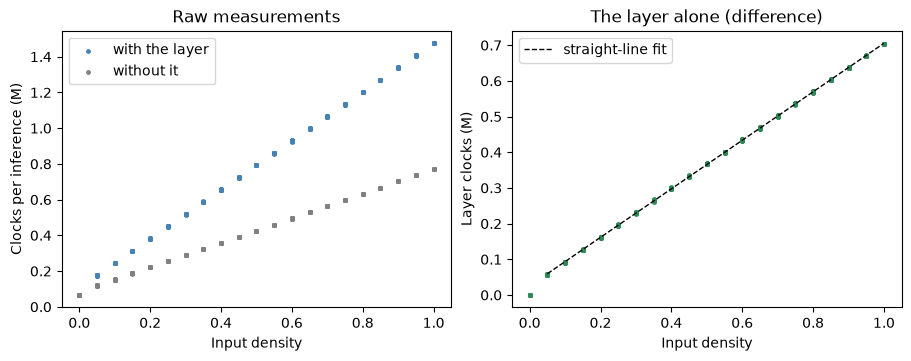

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(9, 3.5), constrained_layout=True)
axs[0].scatter(input_density, with_layer / 1e6, s=6, color='steelblue', label='with the layer')
axs[0].scatter(input_density, without_layer / 1e6, s=6, color='gray', label='without it')
axs[0].set(xlabel='Input density', ylabel='Clocks per inference (M)',
           title='Raw measurements')
axs[0].legend()
axs[1].scatter(input_density, layer_clocks / 1e6, s=6, color='seagreen')
xs = np.array([0.05, 1.0])
axs[1].plot(xs, (slope * xs + intercept) / 1e6, 'k--', lw=1, label='straight-line fit')
axs[1].set(xlabel='Input density', ylabel='Layer clocks (M)',
           title='The layer alone (difference)')
axs[1].legend()
plt.show()

The layer's time is a straight line in the number of events it receives: every event costs
the same, wherever it falls. With no events at all the layer costs next to nothing. As soon
as it has any, there is a small fixed cost (the intercept), and the rest is per event.

The model *without* the layer under test also rises with density, because the separable
layer in front of it is event-based too. Its value at zero density is the input layer plus
the fixed cost of running an inference. The input layer runs on its own dedicated unit and
is a conventional convolution: its cost doesn't change with density.

### The cost of an event depends on the kernel

The same measurement for other kernel sizes, and for a separable layer:

In [6]:
per_event_cost, kernel_sizes = {}, {}
for label, layer_type, kernel_size in [('conv 1x1', 'conv', 1), ('conv 3x3', 'conv', 3),
                                      ('conv 5x5', 'conv', 5), ('conv 7x7', 'conv', 7),
                                      ('separable 3x3', 'sepconv', 3)]:
    test_model = shu.build_single_layer_model(HEIGHT, WIDTH, CHANNELS, FILTERS,
                                              kernel_size=kernel_size, layer_type=layer_type)
    w, wo = shu.layer_clocks(test_model, device, inputs, layer_index=2)
    k_slope, _ = shu.fit_line(input_density[has_events], (w - wo)[has_events])
    per_event_cost[label] = k_slope / events_at_full_density / FILTERS
    kernel_sizes[label] = kernel_size

# A dense convolution does k x k MACs per input value per filter: how many of those
# does an event get through per clock?
print(f'{"Layer":<15}{"clocks per event per filter":>30}{"dense MACs per clock":>24}')
for label, cost in per_event_cost.items():
    macs = f'{kernel_sizes[label] ** 2 / cost:.1f}' if label.startswith('conv') else '-'
    print(f'{label:<15}{cost:>30.3f}{macs:>24}')

Layer             clocks per event per filter    dense MACs per clock
conv 1x1                                0.386                     2.6
conv 3x3                                0.648                    13.9
conv 5x5                                2.240                    11.2
conv 7x7                                9.269                     5.3
separable 3x3                           0.646                       -


Two things to take from this table:

- **3 × 3 is the efficient kernel on Akida 1.** It gets through the most dense-equivalent
  MACs per clock. Larger kernels cost more per event than their k² alone would suggest, and
  1 × 1 saves much less than k² would.
- **A separable layer costs about the same per event as a full convolution with the same
  number of filters.** On Akida 1 the depthwise and pointwise parts of a separable layer are
  fused and run together, so the saving you'd expect from a GPU doesn't happen here.
  Akida 2 runs them as two separate layers.

## 2. Energy follows the events too

On an AKD1500 with power sensing, `full_model_benchmark` in `brainchip_utils` records the
chip's power during inference and while it is idle just before and after. The difference
is the **dynamic** power, the power spent on the inferences themselves, and multiplied by the
inference time it gives the dynamic energy per inference. `shu.layer_energy` does that
for the models with and without the layer under test, and subtracts.

In [7]:
ENERGY_DENSITIES = [0.0, 0.25, 0.5, 0.75, 1.0]

layer_energy_mj = []
for density in ENERGY_DENSITIES:
    energy_inputs = shu.random_events((HEIGHT, WIDTH, 1), density, num_samples=100, seed=1)
    result = shu.layer_energy(model, device, energy_inputs, layer_index=2)
    if result is None:
        print('Power measurement not available on this device: skipping the energy cells.')
        break
    layer_energy_mj.append(result[0] - result[1])

 Density   Layer dynamic energy (uJ per inference)
    0.00                                       0.0
    0.25                                      12.6
    0.50                                      28.7
    0.75                                      46.3
    1.00                                      61.9


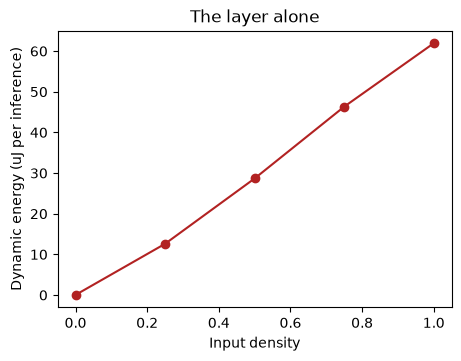

In [8]:
if len(layer_energy_mj) == len(ENERGY_DENSITIES):
    print(f'{"Density":>8}{"Layer dynamic energy (uJ per inference)":>42}')
    for density, energy in zip(ENERGY_DENSITIES, layer_energy_mj):
        print(f'{density:>8.2f}{energy * 1e3:>42.1f}')

    fig, ax = plt.subplots(figsize=(4.5, 3.5), constrained_layout=True)
    ax.plot(ENERGY_DENSITIES, np.array(layer_energy_mj) * 1e3, 'o-', color='firebrick')
    ax.set(xlabel='Input density', ylabel='Dynamic energy (uJ per inference)',
           title='The layer alone')
    plt.show()

Dynamic energy rises with the density in the same way as time: a busy NP draws roughly
constant power, so its energy follows its clock count. The idle (static) power is paid for
every millisecond the chip runs, so the *total* energy per inference also scales with
latency. Fewer events save both.

### An aside: zero *weights* save energy, not time

Activation sparsity isn't the only kind. Here the layer under test gets three sets of
weights: random, random with half of them set to zero, and an identity kernel (almost all
zero). The input is fully dense, so only the weights change.

In [9]:
dense_inputs = shu.random_events((HEIGHT, WIDTH, 1), 1.0, num_samples=100, seed=2)
rng = np.random.default_rng(3)

for label in ['random', 'half zero', 'identity']:
    weight_model = shu.build_single_layer_model(HEIGHT, WIDTH, CHANNELS, FILTERS, kernel_size=3)
    layer = weight_model.layers[-1]
    weights = layer.get_variable('weights')
    if label == 'half zero':
        weights = weights * (rng.random(weights.shape) < 0.5)
    elif label == 'identity':
        weights = np.zeros_like(weights)
        weights[1, 1, np.arange(CHANNELS), np.arange(FILTERS)] = 1
    layer.set_variable('weights', weights.astype(np.int8))
    nonzero = np.count_nonzero(weights) / weights.size

    result = shu.benchmark(shu.sub_model(weight_model, 3), device, dense_inputs)
    energy = (f"{result['power']['avg_dynamic_energy_mj'] * 1e3:.1f} uJ"
              if result['power'] is not None else 'n/a')
    print(f'>> {label:<10} non-zero weights {nonzero:5.0%}   '
          f"clocks {result['mean_inf_clk']:,.0f}   dynamic energy {energy}")

>> random     non-zero weights   81%   clocks 1,475,340   dynamic energy 74.6 uJ
>> half zero  non-zero weights   41%   clocks 1,475,428   dynamic energy 62.8 uJ
>> identity   non-zero weights    0%   clocks 1,469,182   dynamic energy 34.9 uJ


In this test the clock count barely moves, whatever the weights: on Akida 1, time is set
by the events. The dynamic energy drops as weights go to zero. So weight sparsity (pruning) can save some energy, but only
activation sparsity saves time *and* energy.

## 3. Compared with a dense array of multipliers

How good is that time? One yardstick is the time an array of multipliers would need to
compute the same layer densely, every input value times every weight. Each Akida 1 NP has
32 multiply-accumulate (MAC) units. A 3 × 3 convolution needs
`height × width × channels × filters × 9` MACs, so a perfectly used 32-MAC array needs that
number divided by 32 clocks, whatever the input.

The ratio of that ideal dense time to the measured time gives the NP's efficiency relative
to the dense array:

Ideal dense time on 1 NP(s): 294,912 clocks
Break-even density: 0.40
At density 0.25: 151% of the dense array
At density 0.50: 80% of the dense array
At density 1.00: 42% of the dense array


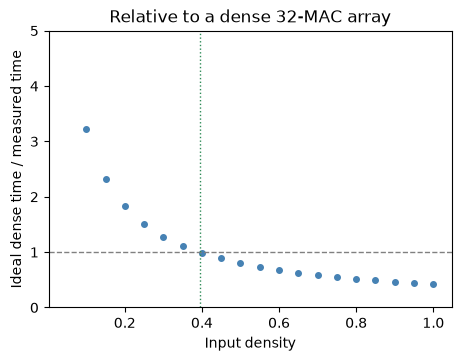

In [10]:
nps = shu.layer_nps(model)[2]
dense_macs = HEIGHT * WIDTH * CHANNELS * FILTERS * 3 * 3
ideal_dense_clocks = dense_macs / (32 * nps)

mean_layer_clocks = np.array([layer_clocks[input_density == d].mean() for d in DENSITIES])
relative_efficiency = ideal_dense_clocks / mean_layer_clocks[1:]
break_even = (ideal_dense_clocks - intercept) / slope

print(f'Ideal dense time on {nps} NP(s): {ideal_dense_clocks:,.0f} clocks')
print(f'Break-even density: {break_even:.2f}')
for density in [0.25, 0.5, 1.0]:
    idx = np.flatnonzero(DENSITIES[1:] == density)[0]
    print(f'At density {density:.2f}: {relative_efficiency[idx]:.0%} of the dense array')

fig, ax = plt.subplots(figsize=(4.5, 3.5), constrained_layout=True)
ax.plot(DENSITIES[1:], relative_efficiency, 'o', ms=4, color='steelblue')
ax.axhline(1.0, color='gray', ls='--', lw=1)
ax.axvline(break_even, color='seagreen', ls=':', lw=1)
ax.set(xlabel='Input density', ylabel='Ideal dense time / measured time',
       ylim=(0, 5), title='Relative to a dense 32-MAC array')
plt.show()

With every input non-zero, the NP is well short of a perfectly used dense array: Akida
isn't built to win on dense data. Below the break-even density it finishes sooner than
that ideal array could, and it keeps improving as the density falls. Real layers often
run at or below that density, as the next section shows. That's why, on Akida, the number
of events, not the number of MACs, is the measure of a layer's cost.

## 4. A real model: Visual Wake Words

Now the same questions for a trained model, the AkidaNet (alpha 0.25, 96 × 96) from the
[VWW example](../../model_zoo/vww), on real images. The pretrained `.fbz` comes through
Git LFS.

In [11]:
vww_model = akida.Model('../../model_zoo/vww/pretrained_models/akidanet_vww_qat.fbz')
NUM_IMAGES = 500
images = get_samples('../../model_zoo/vww/data/vw_coco2014_96', tuple(vww_model.input_shape),
                     num_samples=NUM_IMAGES)

vww_model.map(device, mode=akida.MapMode.Minimal)
vww_model.summary()
vww_nps = shu.layer_nps(vww_model)

Found 109619 images belonging to 2 classes.
                                     Model Summary                                     
_______________________________________________________________________________________
Input shape  Output shape  Sequences  Layers  NPs  Skip DMAs  External Memory (Bytes)
[96, 96, 3]  [1, 1, 2]     1          15      16   0          0                      
_______________________________________________________________________________________

_________________________
Component (type)  Count
HRC               1    
_________________________
CNP1              15   
_________________________
FNP3              1    
_________________________

______________________________________________________________________
Layer (type)              Output shape  Kernel shape      Components

======== HW/conv_0-predictions (Hardware) - size: 180224 bytes =======

conv_0 (InputConv.)       [48, 48, 8]   (3, 3, 3, 8)      1 HRC     
____________________________________

### One layer, image by image

Take `separable_4`, the slowest layer in this model. Time it by subtraction on 200
images, twice over.

Layer clocks per image: 423,589 to 517,125
Median difference between the two runs, same image: 394 clocks


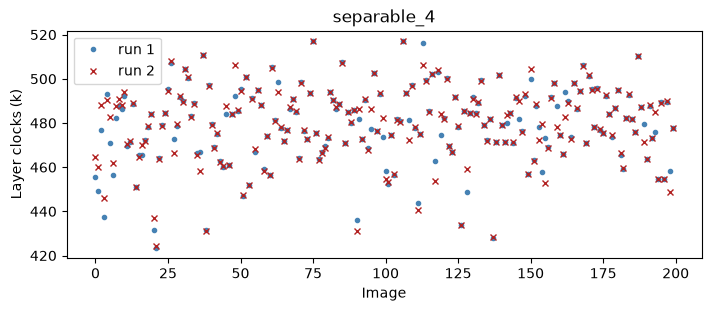

In [12]:
LAYER = [layer.name for layer in vww_model.layers].index('separable_4')
test_images = images[:200]

run_1 = np.subtract(*shu.layer_clocks(vww_model, device, test_images, LAYER))
run_2 = np.subtract(*shu.layer_clocks(vww_model, device, test_images, LAYER))
print(f'Layer clocks per image: {run_1.min():,.0f} to {run_1.max():,.0f}')
print(f'Median difference between the two runs, same image: '
      f'{np.median(np.abs(run_1 - run_2)):,.0f} clocks')

fig, ax = plt.subplots(figsize=(7, 3), constrained_layout=True)
ax.plot(run_1 / 1e3, '.', color='steelblue', label='run 1')
ax.plot(run_2 / 1e3, 'x', ms=4, color='firebrick', label='run 2')
ax.set(xlabel='Image', ylabel='Layer clocks (k)', title=vww_model.layers[LAYER].name)
ax.legend()
plt.show()

The time varies from one image to the next, but the same image always takes the same
time, to within a few hundred clocks. So the variation comes from the images. The obvious
candidate is how many events each image produces at this layer's input:

Input density at this layer: 0.60 on average
Correlation of clocks with events: 0.99
Clocks per event per filter: 0.648 (hand-built 3x3 layer: 0.648)


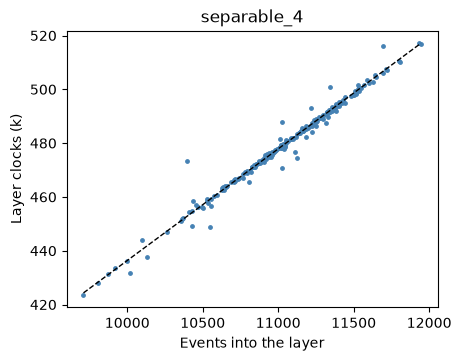

In [13]:
events = shu.input_events(vww_model, test_images, LAYER)
layer = vww_model.layers[LAYER]
real_slope, real_intercept = shu.fit_line(events, run_1)
real_cost = real_slope / layer.output_dims[2] * vww_nps[LAYER]

print(f'Input density at this layer: {events.mean() / np.prod(layer.input_dims):.2f} on average')
print(f'Correlation of clocks with events: {np.corrcoef(events, run_1)[0, 1]:.2f}')
print(f'Clocks per event per filter: {real_cost:.3f} '
      f'(hand-built 3x3 layer: {clocks_per_event_per_filter:.3f})')

fig, ax = plt.subplots(figsize=(4.5, 3.5), constrained_layout=True)
ax.scatter(events, run_1 / 1e3, s=6, color='steelblue')
xs = np.array([events.min(), events.max()])
ax.plot(xs, (real_slope * xs + real_intercept) / 1e3, 'k--', lw=1)
ax.set(xlabel='Events into the layer', ylabel='Layer clocks (k)', title=layer.name)
plt.show()

The image-to-image variation is the events. And the cost per event per filter is close to
the hand-built layer's: the rule you measured on synthetic data holds on a trained layer
with real inputs. (`separable_4` has a stride of 2. The cost is counted per *input* event,
because that's what an event-based layer processes.)

### Every layer

If every event costs about the same per filter, a layer's time should be roughly
`events × filters / NPs × cost per event per filter`. Dividing by the NPs works because
a layer split across several NPs shares out either its events (a spatial split) or its
filters. `per_layer_benchmark` from `brainchip_utils`, the same function the model zoo
benchmarks use, times every layer of the model by subtraction:

In [14]:
per_layer = per_layer_benchmark(vww_model, device, images, repeats=NUM_IMAGES, clock_freq=CLOCK_HZ)
cumulative = per_layer['cumulative_clocks']                     # layers x images
measured = np.diff(cumulative, axis=0, prepend=0).mean(axis=1)  # mean clocks per layer

filters = np.array([layer.output_dims[2] for layer in vww_model.layers])
layer_events = np.stack([shu.input_events(vww_model, images, kk) if kk > 0 else np.zeros(NUM_IMAGES)
                         for kk in range(len(vww_model.layers))])
predicted = (layer_events * filters[:, None] / np.maximum(vww_nps, 1)[:, None]).mean(axis=1)
predicted *= clocks_per_event_per_filter


Layer            Latency (ms)       Clocks
----------------------------------
conv_0                 0.1786
conv_1                 0.2278
conv_2                 0.8105
conv_3                 0.4907
separable_4            1.1963
separable_5            0.7272
separable_6            0.7623
separable_7            0.6945
separable_8            0.6008
separable_9            0.4736
separable_10           0.4237
separable_11           0.3246
separable_12           0.9418
separable_13           0.1587
predictions            0.0208
----------------------------------
Total                  8.0320


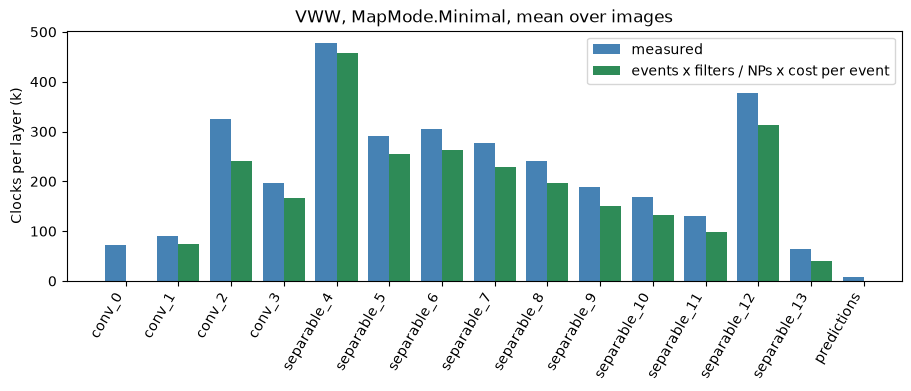

In [15]:
names = per_layer['layer_names']
# The input layer and the fully connected classifier run on other kinds of unit: no prediction
standard = np.array([layer.parameters.layer_type in (akida.LayerType.Convolutional,
                                                     akida.LayerType.SeparableConvolutional)
                     for layer in vww_model.layers])

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(9, 3.8), constrained_layout=True)
ax.bar(x - 0.2, measured / 1e3, width=0.4, color='steelblue', label='measured')
ax.bar(x[standard] + 0.2, predicted[standard] / 1e3, width=0.4, color='seagreen',
       label='events x filters / NPs x cost per event')
ax.set_xticks(x, names, rotation=60, ha='right')
ax.set(ylabel='Clocks per layer (k)', title='VWW, MapMode.Minimal, mean over images')
ax.legend()
plt.show()

From a single cost per event, measured on a hand-built layer, the prediction follows the
profile of the whole network: which layers are expensive and by roughly how much. It runs a
little low throughout, so there are costs the simple model leaves out, and it is furthest
off for `conv_2`, which is split over two NPs (see the NP counts in the summary above).

The same holds image by image for the whole model:

In [16]:
total_clocks = cumulative[-1]
predicted_per_image = (layer_events * filters[:, None] / np.maximum(vww_nps, 1)[:, None])[standard].sum(axis=0)
print(f'Whole model: {total_clocks.min() / CLOCK_HZ * 1e3:.2f} to {total_clocks.max() / CLOCK_HZ * 1e3:.2f} ms per image')
print(f'Correlation with events x filters / NPs: {np.corrcoef(predicted_per_image, total_clocks)[0, 1]:.2f}')

Whole model: 7.52 to 8.35 ms per image
Correlation with events x filters / NPs: 0.95


## 5. Switching the sparsity off (and turning it up)

The trained model's activations are already sparse. What is that worth? To find out without
retraining, `shu.shift_thresholds` moves every layer's firing threshold by whole activation
steps: up makes neurons fire less often, down more often, and `None` makes every neuron
always fire, so every activation is non-zero. The weights and the mapping don't change, only
the activity.

This breaks the model's accuracy: it is a probe of the hardware, not a way to make a model
sparser. For that, see the tutorial on developing sparse models.

In [17]:
sweep = []
for steps in [4, 2, 1, 0, -1, -2, -4, -8, None]:
    swept_model = shu.shift_thresholds(vww_model, steps)
    density = shu.activation_density(swept_model, images[:50]).mean()
    result = shu.benchmark(swept_model, device, images[:200])
    power = result['power']
    sweep.append(dict(steps=steps, density=density, latency_ms=result['mean_clk_ms'],
                      dynamic_mj=power['avg_dynamic_energy_mj'] if power else np.nan,
                      total_mj=power['avg_energy_mj'] if power else np.nan))

 Threshold shift  Mean density  Latency (ms)  Dynamic E (mJ)  Total E (mJ)
              +4          0.21          3.86           0.091         0.534
              +2          0.31          5.73           0.139         0.793
              +1          0.38          6.91           0.171         0.956
              +0          0.44          8.03           0.199         1.110
              -1          0.48          8.63           0.214         1.193
              -2          0.52          8.98           0.223         1.242
              -4          0.59          9.66           0.242         1.336
              -8          0.68         10.92           0.274         1.510
        all fire          1.00         16.74           0.407         2.298


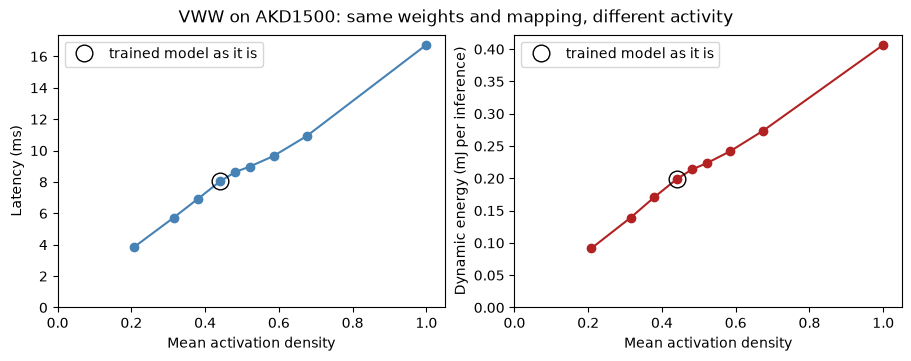

In [18]:
print(f'{"Threshold shift":>16}{"Mean density":>14}{"Latency (ms)":>14}'
      f'{"Dynamic E (mJ)":>16}{"Total E (mJ)":>14}')
for row in sweep:
    shift = 'all fire' if row['steps'] is None else f"{row['steps']:+d}"
    print(f"{shift:>16}{row['density']:>14.2f}{row['latency_ms']:>14.2f}"
          f"{row['dynamic_mj']:>16.3f}{row['total_mj']:>14.3f}")

density = np.array([row['density'] for row in sweep])
trained = [row['steps'] == 0 for row in sweep].index(True)
fig, axs = plt.subplots(1, 2, figsize=(9, 3.5), constrained_layout=True)
for ax, key, label, color in [(axs[0], 'latency_ms', 'Latency (ms)', 'steelblue'),
                              (axs[1], 'dynamic_mj', 'Dynamic energy (mJ per inference)', 'firebrick')]:
    values = np.array([row[key] for row in sweep])
    ax.plot(density, values, 'o-', color=color)
    ax.plot(density[trained], values[trained], 'o', ms=12, mfc='none', color='k',
            label='trained model as it is')
    ax.set(xlabel='Mean activation density', ylabel=label, xlim=(0, 1.05), ylim=(0, None))
    ax.legend(loc='upper left')
fig.suptitle('VWW on AKD1500: same weights and mapping, different activity')
plt.show()

Latency and energy follow the activity, from the sparsest setting to fully dense. Compare
the trained model, circled, with the `all fire` row: the activation sparsity the model
already has is worth about half its latency and half its energy. And every step further
down in density pays off. Training for sparsity, with activity regularisation, is how to
get there while keeping the accuracy under control.

## What this means for your models

- **Benchmark with real inputs.** Time and energy depend on the data. Random or synthetic
  inputs drive unrepresentative activity, and give misleading numbers.
- **A layer's cost is `events × filters / NPs`, times a cost per event set by the kernel.**
  The layers that dominate are the ones with many events, many filters and few NPs. Every
  model zoo example's benchmark notebook shows the per-layer timing.
- **Activation sparsity is a design target.** It saves time and energy in proportion.
  The tutorial *Developing sparse models* (🚧 In review, see the
  [tutorials list](../../README.md#tutorials)) shows how to train for it.
- **The input layer doesn't benefit.** It runs on its own unit as a conventional
  convolution, whatever the density of its input.
- **On Akida 1, prefer 3 × 3 kernels**, and don't expect separable layers to be cheaper
  than full convolutions with the same number of filters.
- **Zero weights save some energy, but not time.**

The principle is the same on Akida 2: standard NPs process events. The details differ:
inputs are 8-bit, separable layers are split into depthwise and pointwise layers, and the
costs per event haven't been measured here.